In [1]:
from __future__ import print_function
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.regularizers import l2
import numpy as np
import os
import matplotlib.pyplot as plt

tf.config.set_soft_device_placement(True)
%matplotlib inline

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_train.shape[0]

50000

In [6]:
batch_size = 32
num_classes = 10
epochs = 1

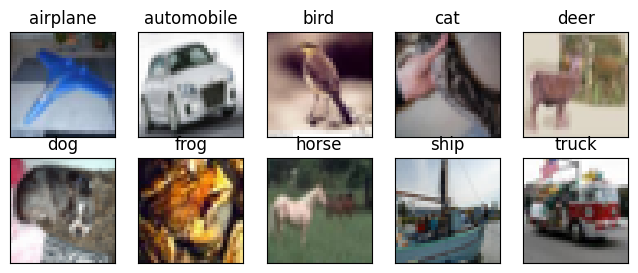

In [7]:
# plotting some random 10 images

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

fig = plt.figure(figsize=(8, 3))
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    idx = np.where(y_train[:] == i)[0]
    features_idx = x_train[idx, ::]
    img_num = np.random.randint(features_idx.shape[0])
    im = features_idx[img_num, ::]
    ax.set_title(class_names[i])
    plt.imshow(im)
plt.show()

In [8]:
import logging

logging.getLogger().setLevel(logging.INFO)

In [9]:
# TEst
a = tf.constant([[1.0, 2.0]])
b = tf.constant([[3.0], [4.0]])
c = tf.matmul(a, b)

print("Result:", c.numpy())

2026-05-23 04:46:34.788428: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-23 04:46:34.788458: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-23 04:46:34.788462: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-23 04:46:34.788480: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-23 04:46:34.788490: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Result: [[11.]]


In [10]:
# size = 5000
# matrix_a = tf.random.normal([size, size])
# matrix_b = tf.random.normal([size, size])
# print(tf.matmul(matrix_a,matrix_b))

tf.Tensor(
[[ -89.705826    45.473984    34.271637  ...  -29.417395    55.379425
    22.718702 ]
 [  47.713547   -56.99717    -29.457022  ...  118.36274     -1.5544672
  -152.2927   ]
 [-106.68185     29.028801    47.732864  ...   63.677753  -118.59228
    76.2186   ]
 ...
 [ -46.104992   -88.61368    120.89849   ...   62.195137   -50.49715
   -85.9529   ]
 [  85.01629     49.383453    19.508232  ...  -22.390137     3.9094996
   -16.730467 ]
 [  -7.3466325  -48.054104   -20.142988  ...  -55.490955     9.734607
    34.756275 ]], shape=(5000, 5000), dtype=float32)


In [11]:
x_train.shape

(50000, 32, 32, 3)

In [12]:
y_train[0]

array([6], dtype=uint8)

In [22]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [23]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [68]:
model = Sequential()
model.add(tf.keras.Input(shape=(x_train.shape[1:])))
model.add(Conv2D(64, kernel_size=(3, 3), padding="same", name="layer_1"))
model.add(Activation(tf.nn.relu))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3)))
model.add(Activation(tf.nn.relu))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.5))

model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())

model.add(Dense(units=512, kernel_regularizer=l2(0.01)))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation(tf.nn.softmax, name="with_logits"))

In [69]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ with_logits (Activation)        │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,378 (10.02 MB)

 Trainable params: 2,625,738 (10.02 MB)

 Non-trainable params: 640 (2.50 KB)

When you bypass Keras and write pure, low-level TensorFlow, you drop the high-level configurations completely. There is no model.compile() or model.fit(). Instead, you have to manually handle the forward pass, calculate gradients via tf.GradientTape, and explicitly apply those updates using the optimizer.
The fundamental differences look like this in raw TensorFlow:
1. The Loss Function
Because you aren't using Keras to parse strings, you interact directly with mathematical operations on tensors.
# String equivalent ("categorical_crossentropy")
# You call the functional interface directly on predictions and labels
loss_value = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true, y_pred))

# Class Instance equivalent (tf.keras.losses.CategoricalCrossentropy())
# You instantiate an object wrapper, then pass the tensors
cce = tf.keras.losses.CategoricalCrossentropy()
loss_value = cce(y_true, y_pred)

Note: Even in "pure" TF, we often use the loss mathematical functions from the tf.keras.losses or tf.nn module to avoid manually writing out the raw LaTeX formula - \sum y_{true} \log(y_{pred}) every time.
2. The Optimizer
In direct TensorFlow, the optimizer is no longer a configurations argument; it is a live actor that executes mathematical adjustments on your weights matrix.
# Pure TF instantiation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Inside your manual training loop, you explicitly pass the calculated gradients
# and the model's trainable weights to the optimizer:
optimizer.apply_gradients(zip(gradients, model.trainable_variables))

3. Metrics
Metrics in pure TF act as persistent accumulators. They don't just calculate a value for a single batch; they maintain an internal state across multiple steps until you explicitly reset them.

```
# Instantiating the metric accumulator
train_acc_metric = tf.keras.metrics.CategoricalAccuracy()

# Inside your batch loop, you update the running state:
train_acc_metric.update_state(y_true, y_pred)

# At the end of an epoch, you extract the calculated metric value:
epoch_accuracy = train_acc_metric.result().numpy()

# You must manually reset it for the next epoch:
train_acc_metric.reset_state()

Putting it together: The Pure TF Training Workflow
To see how these concepts tie together without Keras abstractions, this is how you actually execute a training step using standard tf.GradientTape:
import tensorflow as tf

# 1. Initialize components
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.CategoricalCrossentropy()
accuracy_metric = tf.keras.metrics.CategoricalAccuracy()

# 2. Explicit training step function

@tf.function # Compiles into a fast static graph
def train_step(x_batch, y_batch, model_variables):
    with tf.GradientTape() as tape:
        # Forward pass (manual prediction calculation)
        predictions = my_pure_tf_model(x_batch, model_variables)
        loss = loss_fn(y_batch, predictions)

    # Backward pass (calculate gradients of loss with respect to variables)
    gradients = tape.gradient(loss, model_variables)

    # Apply updates to weights
    optimizer.apply_gradients(zip(gradients, model_variables))

    # Update running tracking metrics
    accuracy_metric.update_state(y_batch, predictions)

    return loss
```

In [90]:
# Configure your training data pipeline
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(buffer_size=50000)
    .batch(64)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [91]:
# Grab a single sample batch to inspect shapes
for sample_images, sample_labels in train_dataset.take(1):
    print("Images shape:", sample_images.shape)  # Expected: (64, 32, 32, 3)
    print("Labels shape:", sample_labels.shape)  # Expected: (64, 10)

Images shape: (64, 32, 32, 3)
Labels shape: (64, 10)


2026-05-23 06:55:03.831643: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [70]:
# # 1. Initialize components
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
# loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False, label_smoothing=0.1)
#
# # Persistent accumulators for evaluation
# train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
# train_acc_metric = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')
#
# # 2. Explicit training step function
#
# @tf.function # Compiles into a fast static graph
# def train_step(x_batch, y_batch):
#     with tf.GradientTape() as tape:
#         # Forward pass (manual prediction calculation)
#         predictions = model(x_batch)
#         loss = loss_fn(y_batch, predictions)
#
#     # Backward pass (calculate gradients of loss with respect to variables)
#     gradients = tape.gradient(loss, model.trainable_variables)
#
#     # Apply updates to weights
#     optimizer.apply_gradients(zip(gradients, model.trainable_variables))
#
#     # Update running tracking metrics
#     accuracy_metric.update_state(y_batch, predictions)
#
#
#     return loss

In [92]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)
loss_fn = tf.keras.losses.CategoricalCrossentropy(
    from_logits=False, label_smoothing=0.1
)

# Persistent accumulators for evaluation
train_loss_metric = tf.keras.metrics.Mean(name="train_loss")
train_acc_metric = tf.keras.metrics.CategoricalAccuracy(name="train_accuracy")

In [93]:
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        # 1. Forward Pass (Set training=True to activate Dropout and BatchNorm)
        predictions = model(x_batch, training=True)

        # 2. Compute Base Loss + Regularization Losses (like the L2 penalty on your Dense layer)
        base_loss = loss_fn(y_batch, predictions)
        reg_loss = tf.add_n(model.losses) if model.losses else 0.0
        total_loss = base_loss + reg_loss

    # 3. Backward Pass: Compute gradients with respect to trainable weights
    gradients = tape.gradient(total_loss, model.trainable_variables)

    # 4. Optimization: Apply weight modifications
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # 5. Update running metrics state
    train_loss_metric.update_state(total_loss)
    train_acc_metric.update_state(y_batch, predictions)

In [94]:
y_train.shape

(50000, 10)

In [95]:
# Assuming 'train_dataset' is a batched tf.data.Dataset pipeline
epochs = 10

for epoch in range(epochs):
    # Reset metric states at the start of each epoch
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()

    for step, (x_batch, y_batch) in enumerate(train_dataset):
        train_step(x_batch, y_batch)

    # Log metrics after iterating through all mini-batches
    print(
        f"Epoch {epoch + 1} "
        f"- Loss: {train_loss_metric.result():.4f} "
        f"- Accuracy: {train_acc_metric.result():.4f}"
    )

2026-05-23 06:55:55.924848: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1 - Loss: 122.4213 - Accuracy: 0.1208


2026-05-23 06:56:19.510332: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2 - Loss: 3.1694 - Accuracy: 0.1351


2026-05-23 06:56:44.813533: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-05-23 06:57:36.116885: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 5 - Loss: 9.3868 - Accuracy: 0.0995


2026-05-23 06:58:00.523348: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 6 - Loss: 11.1211 - Accuracy: 0.0989


KeyboardInterrupt: 

In [71]:
# 2. Define a single, compiled training step for maximum speed
@tf.function  # Compiles the Python code into a fast, static execution graph
def train_step(x_batch, y_batch, model):
    # Open the GradientTape context to record operations
    with tf.GradientTape() as tape:
        # Forward pass: Generate predictions
        predictions = model(x_batch, training=True)
        # Calculate the scalar error score
        loss_value = loss_fn(y_batch, predictions)

    # Backward pass: Extract the partial derivatives (gradients)
    # This calculates dLoss/dWeight for every trainable parameter in the model
    gradients = tape.gradient(loss_value, model.trainable_variables)

    # Optimization step: Modify the actual weights on your hardware
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss_value

In [74]:
# TensorFlow "DataLoader" pipeline
)

In [73]:
epochs = 5

# Assuming 'dataset' is a batched tf.data.Dataset object (e.g., batch_size=64)
for epoch in range(epochs):
    print(f"\nStart of epoch {epoch + 1}")

    # Iterate over the mini-batches of the dataset
    for step, (x_batch, y_batch) in enumerate(data_loader):
        # Execute the manual gradient calculation and optimization step
        loss_value = train_step(x_batch, y_batch, model)

        # Log progress every 100 batches
        if step % 100 == 0:
            print(f"Training loss at step {step}: {float(loss_value):.4f}")


Start of epoch 1


ValueError: in user code:

    File "/var/folders/c2/66z52rgx4y1f5565_87p1_w00000gn/T/ipykernel_6744/2465026132.py", line 12, in train_step  *
        loss_value = loss_fn(y_batch, predictions)
    File "/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/losses/loss.py", line 67, in __call__  **
        losses = self.call(y_true, y_pred)
    File "/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/losses/losses.py", line 33, in call
        return self.fn(y_true, y_pred, **self._fn_kwargs)
    File "/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/losses/losses.py", line 2205, in categorical_crossentropy
        return ops.categorical_crossentropy(
    File "/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/ops/nn.py", line 2104, in categorical_crossentropy
        return backend.nn.categorical_crossentropy(
    File "/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/backend/tensorfl

In [40]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
)

In [19]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
x_train /= 255
x_test /= 255

In [ ]:
train_step(
    x_train,
)

In [42]:
model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=3,
    validation_data=(x_test, y_test),
    shuffle=True,
    verbose=True,
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - categorical_accuracy: 0.4966 - loss: 2.1096 - val_categorical_accuracy: 0.5982 - val_loss: 1.6047
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - categorical_accuracy: 0.6139 - loss: 1.5692 - val_categorical_accuracy: 0.6427 - val_loss: 1.4737
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - categorical_accuracy: 0.6474 - loss: 1.5003 - val_categorical_accuracy: 0.6001 - val_loss: 1.6212


In [43]:
model = Sequential()
model.add(Conv2D(64, (3, 3), padding="same", input_shape=x_train.shape[1:]))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, kernel_regularizer=l2(0.01)))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation("softmax", name="checking_mistake"))

In [44]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ checking_mistake (Activation)   │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,634 (10.02 MB)

 Trainable params: 2,625,866 (10.02 MB)

 Non-trainable params: 768 (3.00 KB)

In [47]:
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
# model.compile(
#   loss=tf.keras.losses.CategoricalCrossentropy(),
#   optimizer=tf.keras.optimizers.Adam(),
#   metrics=[tf.keras.metrics.CategoricalAccuracy()]
# )

In [48]:
model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=3,
    validation_data=(x_test, y_test),
    shuffle=True,
    verbose=True,
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.3376 - loss: 9.7363 - val_accuracy: 0.4196 - val_loss: 6.7739
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4601 - loss: 5.4099 - val_accuracy: 0.5100 - val_loss: 4.1553
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.5430 - loss: 3.3880 - val_accuracy: 0.5966 - val_loss: 2.6265


In [33]:
model.save("cifar.keras")